# Retail Sales Forecasting using Machine Learning

## Objective

The objective of this project is to predict daily sales
for retail stores using historical sales data, promotions,
store characteristics and competitive information.

## Approach

- Data cleaning
- Exploratory data analysis
- Feature engineering
- Machine learning modeling
- Model explainability using SHAP

# 1. Import Libraries

In [180]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning evaluation
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# Model explainability
import shap

# Feature importance analysis
from sklearn.inspection import permutation_importance

# Machine Learning models
import lightgbm as lgb
from lightgbm import LGBMRegressor

# Model persistence
import joblib

# 2. Data Loading


In [181]:
# Afficher toutes les colonnes
pd.set_option('display.max_columns', None)

In [182]:
train = pd.read_csv("train.csv", engine='python')
store = pd.read_csv("store.csv")
test = pd.read_csv("test.csv")

In [183]:
print("Train :", train.shape)
print("Store :", store.shape)
print("Test :", test.shape)

Train : (1017209, 9)
Store : (1115, 10)
Test : (41088, 8)


In [184]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [185]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [186]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


# 3. Data Understanding


In [187]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [188]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [189]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             41088 non-null  int64  
 1   Store          41088 non-null  int64  
 2   DayOfWeek      41088 non-null  int64  
 3   Date           41088 non-null  object 
 4   Open           41077 non-null  float64
 5   Promo          41088 non-null  int64  
 6   StateHoliday   41088 non-null  object 
 7   SchoolHoliday  41088 non-null  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 2.5+ MB


In [190]:
train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [191]:
train.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

In [192]:
store.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [193]:
test.columns

Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday'],
      dtype='object')

In [194]:
train.shape

(1017209, 9)

In [195]:
store.shape

(1115, 10)

In [196]:
test.shape

(41088, 8)

In [197]:
train.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


In [198]:
store.isnull().sum()

,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,3
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544


In [199]:
test.isnull().sum()

,0
Id,0
Store,0
DayOfWeek,0
Date,0
Open,11
Promo,0
StateHoliday,0
SchoolHoliday,0


In [200]:
train.duplicated().sum()

np.int64(0)

In [201]:
store.duplicated().sum()

np.int64(0)

In [202]:
test.duplicated().sum()

np.int64(0)

In [203]:
train.dtypes

,0
Store,int64
DayOfWeek,int64
Date,object
Sales,int64
Customers,int64
Open,int64
Promo,int64
StateHoliday,object
SchoolHoliday,int64


In [204]:
store.dtypes

,0
Store,int64
StoreType,object
Assortment,object
CompetitionDistance,float64
CompetitionOpenSinceMonth,float64
CompetitionOpenSinceYear,float64
Promo2,int64
Promo2SinceWeek,float64
Promo2SinceYear,float64
PromoInterval,object


In [205]:
test.dtypes

,0
Id,int64
Store,int64
DayOfWeek,int64
Date,object
Open,float64
Promo,int64
StateHoliday,object
SchoolHoliday,int64


# 4. Data Cleaning


In [206]:
train_clean = train.copy()
store_clean = store.copy()
test_clean = test.copy()

In [207]:
train_clean["Date"] = pd.to_datetime(train_clean["Date"])
store_clean = store_clean.copy()
test_clean["Date"] = pd.to_datetime(test_clean["Date"])

In [208]:
train_clean.dtypes

,0
Store,int64
DayOfWeek,int64
Date,datetime64[ns]
Sales,int64
Customers,int64
Open,int64
Promo,int64
StateHoliday,object
SchoolHoliday,int64


In [209]:
train_clean["Date"].head()

,Date
0,2015-07-31
1,2015-07-31
2,2015-07-31
3,2015-07-31
4,2015-07-31


In [210]:
train_clean.dtypes

,0
Store,int64
DayOfWeek,int64
Date,datetime64[ns]
Sales,int64
Customers,int64
Open,int64
Promo,int64
StateHoliday,object
SchoolHoliday,int64


# 5. Exploratory Data Analysis (EDA)

The objective of this analysis is to understand sales behavior,
identify temporal patterns, and evaluate the impact of business
factors such as promotions, holidays and store characteristics.

The main questions addressed are:

- How do sales evolve over time?
- Do promotions increase sales?
- Which days generate the highest sales?
- How are sales distributed?
- Do store characteristics impact sales performance?

In [211]:
sales_daily = (
    train_clean
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
)

sales_daily.head()

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


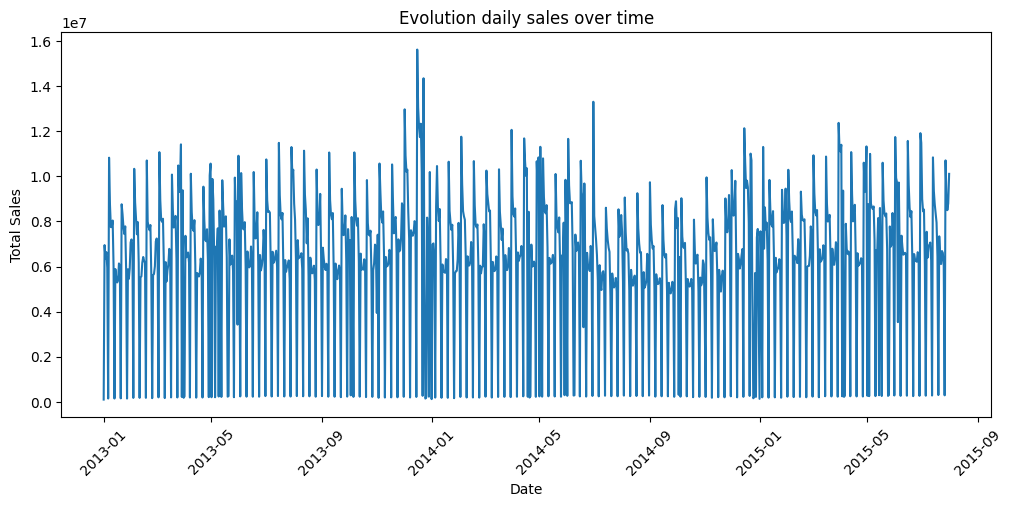

In [212]:
plt.figure(figsize=(12,5))

plt.plot(
    sales_daily["Date"],
    sales_daily["Sales"]
)

plt.title("Evolution daily sales over time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

Sales show strong temporal variations, highlighting the importance
of calendar-based features for forecasting.

These observations justify the use of time-related variables such as
Month, Year, WeekOfYear and DaysSinceStart.

In [213]:
promo_sales = (
    train_clean
    .groupby("Promo")["Sales"]
    .mean()
)

promo_sales

,Sales
Promo,
0,4406.050805
1,7991.152046


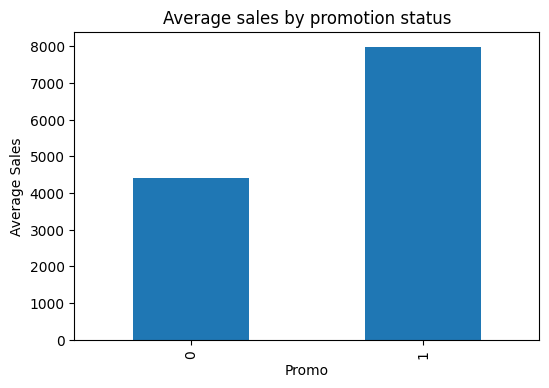

In [214]:
promo_sales.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average sales by promotion status")
plt.xlabel("Promo")
plt.ylabel("Average Sales")

plt.show()

Stores with promotions generally show different sales levels,
confirming that promotional campaigns are an important driver
of customer demand.

In [215]:
weekday_sales = (
    train_clean
    .groupby("DayOfWeek")["Sales"]
    .mean()
)

weekday_sales

,Sales
DayOfWeek,
1,7809.044510
2,7005.244467
3,6555.884138
4,6247.575913
5,6723.274305
6,5847.562599
7,204.183189


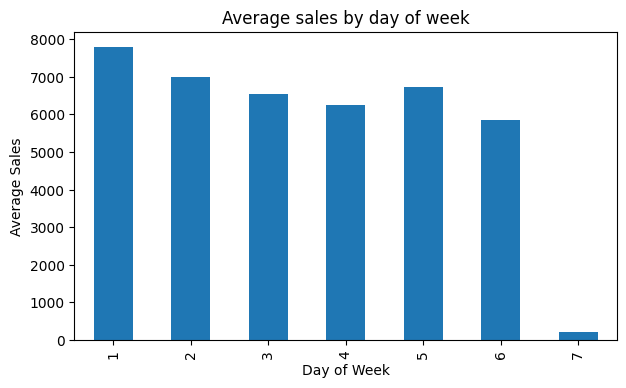

In [216]:
weekday_sales.plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Average sales by day of week")

plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.show()

Sales vary depending on the day of the week,
which supports the integration of weekly seasonality features.

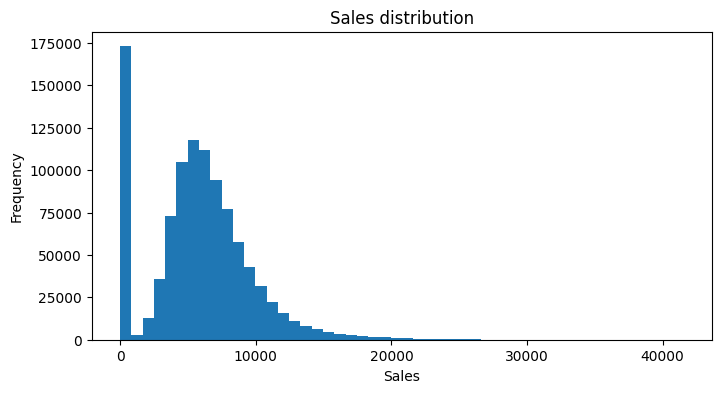

In [217]:
plt.figure(figsize=(8,4))

plt.hist(
    train_clean["Sales"],
    bins=50
)

plt.title("Sales distribution")

plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

Sales are not normally distributed, with a concentration around
average values and some high-sales events.

This confirms the need for a non-linear model such as LightGBM.

# 6. Feature Engineering

New features were created to capture:

- Calendar effects
- Seasonality
- Promotional impact
- Competition effects
- Store characteristics

The main engineered features include:
- Year
- Month
- WeekOfYear
- Quarter
- IsWeekend
- DaysSinceStart
- CompetitionAge
- Promo2Age
- HolidayFlag
- IsPromoMonth

In [218]:
train_merged = train_clean.merge(
    store_clean,
    on="Store",
    how="left"
)

In [219]:
train_merged.shape

(1017209, 18)

In [220]:
train_merged.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [221]:
median_distance = train_merged["CompetitionDistance"].median()

train_merged["CompetitionDistance"] = train_merged["CompetitionDistance"].fillna(median_distance)

In [222]:
train_merged["CompetitionDistance"].isnull().sum()

np.int64(0)

In [223]:
train_merged["Promo2"].value_counts()

,count
Promo2,
1,509178
0,508031


In [224]:
train_merged["Sales"].describe()

,Sales
count,1.017209e+06
mean,5.773819e+03
std,3.849926e+03
min,0.000000e+00
25%,3.727000e+03
50%,5.744000e+03
75%,7.856000e+03
max,4.155100e+04


In [225]:
train_merged[train_merged["Sales"] == 0]["Open"].value_counts()

,count
Open,
0,172817
1,54


In [226]:
train_merged["Year"] = train_merged["Date"].dt.year
train_merged["Month"] = train_merged["Date"].dt.month
train_merged["Day"] = train_merged["Date"].dt.day

In [227]:
train_merged[["Date", "Year", "Month", "Day"]].head()

,Date,Year,Month,Day
0,2015-07-31,2015,7,31
1,2015-07-31,2015,7,31
2,2015-07-31,2015,7,31
3,2015-07-31,2015,7,31
4,2015-07-31,2015,7,31


In [228]:
train_merged["WeekOfYear"] = train_merged["Date"].dt.isocalendar().week

In [229]:
train_merged[["Date", "WeekOfYear"]].head()

,Date,WeekOfYear
0,2015-07-31,31
1,2015-07-31,31
2,2015-07-31,31
3,2015-07-31,31
4,2015-07-31,31


In [230]:
train_merged["Quarter"] = train_merged["Date"].dt.quarter

In [231]:
train_merged[["Date", "Quarter"]].head()

,Date,Quarter
0,2015-07-31,3
1,2015-07-31,3
2,2015-07-31,3
3,2015-07-31,3
4,2015-07-31,3


In [232]:
train_merged[["Date", "WeekOfYear", "Quarter"]].head()

,Date,WeekOfYear,Quarter
0,2015-07-31,31,3
1,2015-07-31,31,3
2,2015-07-31,31,3
3,2015-07-31,31,3
4,2015-07-31,31,3


In [233]:
train_merged["IsWeekend"] = train_merged["DayOfWeek"].apply(
    lambda x: 1 if x >= 6 else 0
)

In [234]:
train_merged["DaysSinceStart"] = (
    train_merged["Date"] - train_merged["Date"].min()
).dt.days

In [235]:
train_merged[
    ["Date", "DayOfWeek", "IsWeekend", "DaysSinceStart"]
].head(10)

,Date,DayOfWeek,IsWeekend,DaysSinceStart
0,2015-07-31,5,0,941
1,2015-07-31,5,0,941
2,2015-07-31,5,0,941
3,2015-07-31,5,0,941
4,2015-07-31,5,0,941
5,2015-07-31,5,0,941
6,2015-07-31,5,0,941
7,2015-07-31,5,0,941
8,2015-07-31,5,0,941
9,2015-07-31,5,0,941


In [236]:
train_merged["IsMonthStart"] = train_merged["Date"].dt.is_month_start.astype(int)

train_merged["IsMonthEnd"] = train_merged["Date"].dt.is_month_end.astype(int)

In [237]:
train_merged[
    ["Date", "IsMonthStart", "IsMonthEnd"]
].head(10)

,Date,IsMonthStart,IsMonthEnd
0,2015-07-31,0,1
1,2015-07-31,0,1
2,2015-07-31,0,1
3,2015-07-31,0,1
4,2015-07-31,0,1
5,2015-07-31,0,1
6,2015-07-31,0,1
7,2015-07-31,0,1
8,2015-07-31,0,1
9,2015-07-31,0,1


In [238]:
train_merged["HasPromo2Start"] = train_merged["Promo2SinceYear"].notna().astype(int)

In [239]:
train_merged["HasPromo2Start"].value_counts()

,count
HasPromo2Start,
1,509178
0,508031


In [240]:
train_merged["Promo2Age"] = (
    train_merged["Year"] - train_merged["Promo2SinceYear"]
)

train_merged["Promo2Age"] = train_merged["Promo2Age"].fillna(0)

In [241]:
train_merged[["Promo2SinceYear", "Year", "Promo2Age"]].head(10)

,Promo2SinceYear,Year,Promo2Age
0,NaN,2015,0.0
1,2010.0,2015,5.0
2,2011.0,2015,4.0
3,NaN,2015,0.0
4,NaN,2015,0.0
5,NaN,2015,0.0
6,NaN,2015,0.0
7,NaN,2015,0.0
8,NaN,2015,0.0
9,NaN,2015,0.0


In [242]:
train_merged["HasCompetition"] = (
    train_merged["CompetitionOpenSinceYear"]
    .notna()
    .astype(int)
)

In [243]:
train_merged["HasCompetition"].value_counts()

,count
HasCompetition,
1,693861
0,323348


In [244]:
train_merged["CompetitionAge"] = (
    train_merged["Year"] - train_merged["CompetitionOpenSinceYear"]
)

train_merged["CompetitionAge"] = train_merged["CompetitionAge"].fillna(0)

In [245]:
train_merged[
    ["CompetitionOpenSinceYear", "Year", "CompetitionAge"]
].head(10)

,CompetitionOpenSinceYear,Year,CompetitionAge
0,2008.0,2015,7.0
1,2007.0,2015,8.0
2,2006.0,2015,9.0
3,2009.0,2015,6.0
4,2015.0,2015,0.0
5,2013.0,2015,2.0
6,2013.0,2015,2.0
7,2014.0,2015,1.0
8,2000.0,2015,15.0
9,2009.0,2015,6.0


In [246]:
train_merged["StoreType"].value_counts()

,count
StoreType,
a,551627
d,312912
c,136840
b,15830


In [247]:
train_merged["Assortment"].value_counts()

,count
Assortment,
a,537445
c,471470
b,8294


In [248]:
train_merged["StateHoliday"].value_counts()

,count
StateHoliday,
0,986159
a,20260
b,6690
c,4100


In [249]:
train_merged["PromoInterval"].value_counts()

,count
PromoInterval,
"Jan,Apr,Jul,Oct",293122
"Feb,May,Aug,Nov",118596
"Mar,Jun,Sept,Dec",97460


In [250]:
train_merged["Date"].min(), train_merged["Date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [251]:
train_merged["HolidayFlag"] = (
    train_merged["StateHoliday"] != "0"
).astype(int)

In [252]:
train_merged[["StateHoliday", "HolidayFlag"]].drop_duplicates()

,StateHoliday,HolidayFlag
0,0,0
63555,a,1
129340,b,1
241055,c,1


In [253]:
month_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sept",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

In [254]:
train_merged["CurrentMonth"] = train_merged["Month"].map(month_map)

In [255]:
train_merged["IsPromoMonth"] = train_merged.apply(
    lambda row: 1
    if pd.notna(row["PromoInterval"]) and row["CurrentMonth"] in row["PromoInterval"]
    else 0,
    axis=1,
)

In [256]:
train_merged[
    ["Month", "CurrentMonth", "PromoInterval", "IsPromoMonth"]
].head(15)

,Month,CurrentMonth,PromoInterval,IsPromoMonth
0,7,Jul,NaN,0
1,7,Jul,"Jan,Apr,Jul,Oct",1
2,7,Jul,"Jan,Apr,Jul,Oct",1
3,7,Jul,NaN,0
4,7,Jul,NaN,0
5,7,Jul,NaN,0
6,7,Jul,NaN,0
7,7,Jul,NaN,0
8,7,Jul,NaN,0
9,7,Jul,NaN,0


In [257]:
categorical_columns = train_merged.select_dtypes(include="object").columns

categorical_columns

Index(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval',
       'CurrentMonth'],
      dtype='object')

In [258]:
model_data = train_merged.copy()

In [259]:
model_data.shape

(1017209, 34)

In [260]:
model_data = model_data.drop(
    columns=[
        "Customers",
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear",
        "Promo2SinceWeek",
        "Promo2SinceYear",
        "PromoInterval",
        "CurrentMonth"
    ]
)

In [261]:
model_data.shape

(1017209, 27)

In [262]:
model_data.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear', 'Quarter', 'IsWeekend',
       'DaysSinceStart', 'IsMonthStart', 'IsMonthEnd', 'HasPromo2Start',
       'Promo2Age', 'HasCompetition', 'CompetitionAge', 'HolidayFlag',
       'IsPromoMonth'],
      dtype='object')

# 7. Data Preparation & Validation Split

A time-based validation strategy is used to simulate a real forecasting scenario.

The model is trained on historical data and evaluated on a future period.
This prevents data leakage.

In [263]:
model_data = model_data.sort_values("Date")

In [264]:
model_data[["Date", "Sales"]].head()

,Date,Sales
1017208,2013-01-01,0
1016473,2013-01-01,0
1016472,2013-01-01,0
1016471,2013-01-01,0
1016470,2013-01-01,0


In [265]:
model_data[["Date", "Sales"]].tail()

,Date,Sales
745,2015-07-31,9082
746,2015-07-31,10708
747,2015-07-31,7481
741,2015-07-31,10460
0,2015-07-31,5263


In [266]:
train_data = model_data[
    model_data["Date"] < "2015-07-01"
]

val_data = model_data[
    model_data["Date"] >= "2015-07-01"
]

In [267]:
train_data.shape, val_data.shape

((982644, 27), (34565, 27))

In [268]:
train_data["Date"].min(), train_data["Date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-06-30 00:00:00'))

In [269]:
val_data["Date"].min(), val_data["Date"].max()

(Timestamp('2015-07-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

## Feature / Target Separation

Sales is the prediction target.
All other variables are used as explanatory features.

In [270]:
y_train = train_data["Sales"]
y_val = val_data["Sales"]

In [271]:
X_train = train_data.drop(columns=["Sales"])
X_val = val_data.drop(columns=["Sales"])

In [272]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((982644, 26), (982644,), (34565, 26), (34565,))

In [273]:
categorical_cols = X_train.select_dtypes(include="object").columns

categorical_cols

Index(['StateHoliday', 'StoreType', 'Assortment'], dtype='object')

In [274]:
categorical_cols = X_train.select_dtypes(include="object").columns

categorical_cols

Index(['StateHoliday', 'StoreType', 'Assortment'], dtype='object')

In [275]:
X_combined = pd.concat(
    [X_train, X_val],
    axis=0
)

In [276]:
X_combined.shape

(1017209, 26)

## Categorical Encoding

Categorical variables are transformed using One-Hot Encoding
to make them usable by machine learning algorithms.

In [277]:
X_encoded = pd.get_dummies(
    X_combined,
    columns=[
        "StateHoliday",
        "StoreType",
        "Assortment"
    ],
    dtype=int
)

In [278]:
X_encoded.shape

(1017209, 34)

In [279]:
X_encoded.columns

Index(['Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'SchoolHoliday',
       'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear',
       'Quarter', 'IsWeekend', 'DaysSinceStart', 'IsMonthStart', 'IsMonthEnd',
       'HasPromo2Start', 'Promo2Age', 'HasCompetition', 'CompetitionAge',
       'HolidayFlag', 'IsPromoMonth', 'StateHoliday_0', 'StateHoliday_a',
       'StateHoliday_b', 'StateHoliday_c', 'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b',
       'Assortment_c'],
      dtype='object')

In [280]:
X_encoded.head()

,Store,DayOfWeek,Date,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,Year,Month,Day,WeekOfYear,Quarter,IsWeekend,DaysSinceStart,IsMonthStart,IsMonthEnd,HasPromo2Start,Promo2Age,HasCompetition,CompetitionAge,HolidayFlag,IsPromoMonth,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c
1017208,1115,2,2013-01-01,0,0,1,5350.0,1,2013,1,1,1,1,0,0,1,0,1,1.0,0,0.0,1,0,0,1,0,0,0,0,0,1,0,0,1
1016473,379,2,2013-01-01,0,0,1,6630.0,0,2013,1,1,1,1,0,0,1,0,0,0.0,0,0.0,1,0,0,1,0,0,0,0,0,1,1,0,0
1016472,378,2,2013-01-01,0,0,1,2140.0,0,2013,1,1,1,1,0,0,1,0,0,0.0,1,1.0,1,0,0,1,0,0,1,0,0,0,0,0,1
1016471,377,2,2013-01-01,0,0,1,100.0,1,2013,1,1,1,1,0,0,1,0,1,3.0,1,3.0,1,0,0,1,0,0,1,0,0,0,0,0,1
1016470,376,2,2013-01-01,0,0,1,160.0,0,2013,1,1,1,1,0,0,1,0,0,0.0,1,1.0,1,0,0,1,0,0,1,0,0,0,1,0,0


In [281]:
X_encoded = X_encoded.drop(columns=["Date"])

In [282]:
X_encoded.shape

(1017209, 33)

In [283]:
train_size = len(X_train)

train_size

982644

In [284]:
X_train_encoded = X_encoded.iloc[:train_size]

X_val_encoded = X_encoded.iloc[train_size:]

In [285]:
X_train_encoded.shape, X_val_encoded.shape

((982644, 33), (34565, 33))

# 8. Machine Learning Modeling

Several machine learning models were evaluated.
A baseline model was first established, then a LightGBM model
was trained to capture complex non-linear relationships
between sales and business features.

LightGBM was selected because of its performance on
tabular data and its ability to handle complex interactions.

## 8.1 Baseline Model

A simple baseline is created by predicting the average sales value
from the training data.

In [286]:
baseline_prediction = np.repeat(
    y_train.mean(),
    len(y_val)
)

rmse_baseline = np.sqrt(
    mean_squared_error(y_val, baseline_prediction)
)

rmse_baseline

np.float64(3626.465645119336)

In [287]:
model_hgb = HistGradientBoostingRegressor(
    learning_rate=0.1,
    max_iter=200,
    max_leaf_nodes=31,
    random_state=42
)

In [288]:
model_hgb.fit(
    X_train_encoded,
    y_train
)

HistGradientBoostingRegressor(max_iter=200, random_state=42)

In [289]:
y_pred_hgb = model_hgb.predict(
    X_val_encoded
)

In [290]:
rmse_hgb = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_hgb
    )
)

rmse_hgb

np.float64(1519.4790165538502)

In [291]:
mae_hgb = mean_absolute_error(
    y_val,
    y_pred_hgb
)

mae_hgb

1113.9310384463724

In [292]:
mape_hgb = np.mean(
    np.abs(
        (y_val - y_pred_hgb) /
        np.where(y_val == 0, 1, y_val)
    )
) * 100

mape_hgb

np.float64(3484.63480555246)

In [293]:
wmape_hgb = (
    np.sum(np.abs(y_val - y_pred_hgb))
    /
    np.sum(y_val)
) * 100

wmape_hgb

np.float64(18.13420871938525)

In [294]:
perm_importance = permutation_importance(
    model_hgb,
    X_val_encoded,
    y_val,
    n_repeats=3,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

In [295]:
importance_df = pd.DataFrame({
    "Feature": X_val_encoded.columns,
    "Importance": perm_importance.importances_mean
})

importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)

,Feature,Importance
2,Open,1851.286807
5,CompetitionDistance,872.237286
0,Store,662.710778
3,Promo,485.748839
6,Promo2,244.244501
1,DayOfWeek,219.009344
30,Assortment_a,179.349857
27,StoreType_b,161.471342
19,CompetitionAge,152.479177
32,Assortment_c,92.251230


In [296]:
results_df = X_val.copy()

results_df["Actual_Sales"] = y_val.values
results_df["Predicted_Sales"] = y_pred_hgb

results_df["Error"] = (
    results_df["Actual_Sales"] -
    results_df["Predicted_Sales"]
)

results_df["Absolute_Error"] = (
    abs(results_df["Error"])
)

In [297]:
results_df.head()

,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Year,Month,Day,WeekOfYear,Quarter,IsWeekend,DaysSinceStart,IsMonthStart,IsMonthEnd,HasPromo2Start,Promo2Age,HasCompetition,CompetitionAge,HolidayFlag,IsPromoMonth,Actual_Sales,Predicted_Sales,Error,Absolute_Error
33821,372,3,2015-07-01,1,1,0,1,d,c,4880.0,1,2015,7,1,27,3,0,911,1,0,1,1.0,1,5.0,0,1,8726,9066.834092,-340.834092,340.834092
33817,368,3,2015-07-01,1,1,0,0,d,c,1450.0,1,2015,7,1,27,3,0,911,1,0,1,6.0,1,10.0,0,0,12302,10491.013330,1810.986670,1810.986670
33818,369,3,2015-07-01,1,1,0,0,d,c,5870.0,0,2015,7,1,27,3,0,911,1,0,0,0.0,1,1.0,0,0,7079,9465.297640,-2386.297640,2386.297640
33819,370,3,2015-07-01,1,1,0,1,d,a,8250.0,1,2015,7,1,27,3,0,911,1,0,1,6.0,1,15.0,0,1,7460,8412.469011,-952.469011,952.469011
33820,371,3,2015-07-01,1,1,0,0,d,c,1970.0,1,2015,7,1,27,3,0,911,1,0,1,1.0,1,6.0,0,0,6899,9299.433467,-2400.433467,2400.433467


In [298]:
store_errors = (
    results_df
    .groupby("Store")
    ["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
)

store_errors.head(10)

,Absolute_Error
Store,
842,6584.891131
788,4944.200268
903,4104.471553
192,3785.859797
578,3619.719191
817,3561.909695
698,3518.702789
827,3466.596578
909,3447.517156


In [299]:
results_df["Error"].mean()

np.float64(-220.73106142703014)

In [300]:
results_df["Absolute_Error"].mean()

np.float64(1113.9310384463724)

## 8.2 LightGBM Model

LightGBM is used as the final model because it provides
high performance for structured/tabular datasets.

In [301]:
lgb_model = LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

## 8.3 Model Training

In [302]:
lgb_model.fit(
    X_train_encoded,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.116029 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 966
[LightGBM] [Info] Number of data points in the train set: 982644, number of used features: 33
[LightGBM] [Info] Start training from score 5760.843202


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=500,
              n_jobs=-1, objective='regression', random_state=42,
              subsample=0.8)

In [303]:
y_pred_lgb = lgb_model.predict(X_val_encoded)

## 8.4 Model Evaluation

In [304]:
rmse_lgb = np.sqrt(
    mean_squared_error(y_val, y_pred_lgb)
)

rmse_lgb

np.float64(1414.1819363813954)

In [305]:
mae_lgb = mean_absolute_error(
    y_val,
    y_pred_lgb
)

mae_lgb

1042.9857839242704

In [306]:
wmape_lgb = (
    np.sum(np.abs(y_val - y_pred_lgb))
    /
    np.sum(y_val)
) * 100

wmape_lgb

np.float64(16.979257462305572)

In [307]:
lgb_base = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1
)

In [308]:
param_grid = {
    "n_estimators": [300, 500, 700, 1000],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "num_leaves": [15, 31, 50, 70, 100],

    "max_depth": [-1, 5, 10, 15],

    "min_child_samples": [20, 50, 100],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [309]:
random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_grid,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

In [310]:
id_to_explain = 0

X_instance = X_shap.iloc[[id_to_explain]]

In [311]:
prediction = lgb_model.predict(
    X_instance
)

prediction

array([8005.04545543])

In [312]:
prediction = lgb_model.predict(
    X_instance
)

prediction

array([8005.04545543])

In [313]:
shap_instance = explainer.shap_values(
    X_instance
)

shap_instance

array([[ 8.88689196e+01,  6.58340390e+01,  9.12316937e+02,
         8.78837942e+02,  8.15682494e+01,  1.56266644e+02,
        -1.96064386e+02,  2.47401480e+00, -3.98297835e+01,
        -1.42117084e+02, -6.55275336e+01, -8.19223526e+00,
         6.71778299e+00,  3.43080114e+02,  3.09760899e-02,
        -1.91786656e+01, -9.97467197e+01, -9.74548316e+01,
         6.89944903e+01,  1.21598609e+01,  4.54368715e+01,
         3.40945128e+00,  8.32469389e+00, -1.88830259e-01,
         0.00000000e+00,  0.00000000e+00, -1.55141683e+01,
        -3.75736706e+01, -4.50878824e+00, -7.66236555e+00,
         1.96995259e+02,  2.05820410e+00,  1.04386865e+02]])

In [314]:
explainer.expected_value

np.float64(5760.843201607118)

In [315]:
shap_instance = explainer.shap_values(
    X_instance
)

In [316]:
explainer.expected_value

np.float64(5760.843201607118)

In [317]:
error_analysis.groupby("Store")["Absolute_Error"] \
.mean() \
.sort_values(ascending=False) \
.head(10)

,Absolute_Error
Store,
842,4809.868089
909,3979.418379
876,3864.072762
192,3835.997453
788,3610.475538
903,3495.107561
578,3493.995061
698,3365.926736
1114,3245.504366


In [318]:
store_errors = (
    error_analysis
    .groupby("Store")["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

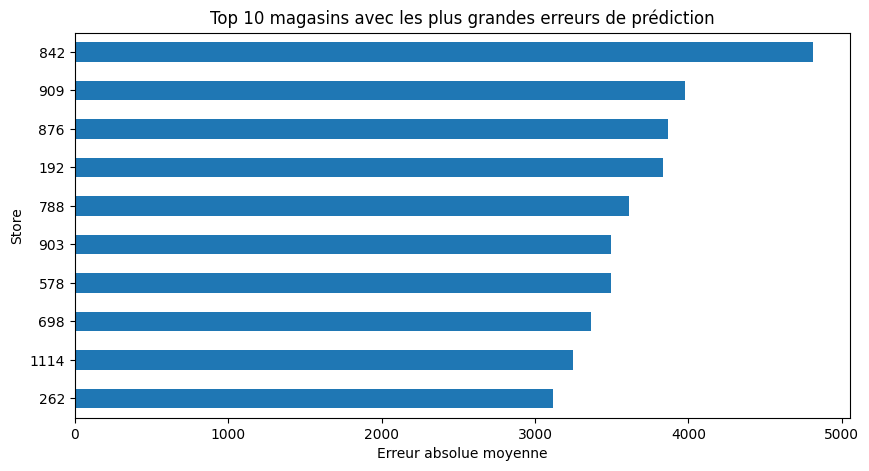

In [319]:
plt.figure(figsize=(10,5))

store_errors.sort_values().plot(
    kind="barh"
)

plt.xlabel("Erreur absolue moyenne")
plt.ylabel("Store")
plt.title("Top 10 magasins avec les plus grandes erreurs de prédiction")

plt.show()


In [320]:
error_analysis["Error"].mean()

np.float64(-236.65442652877076)

# 9. Model Evaluation

The model performance is evaluated using:
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- WMAPE (Weighted Mean Absolute Percentage Error)

Visual analysis is also performed to understand
prediction quality and model behavior.

## 10.1 Actual vs Predicted Sales

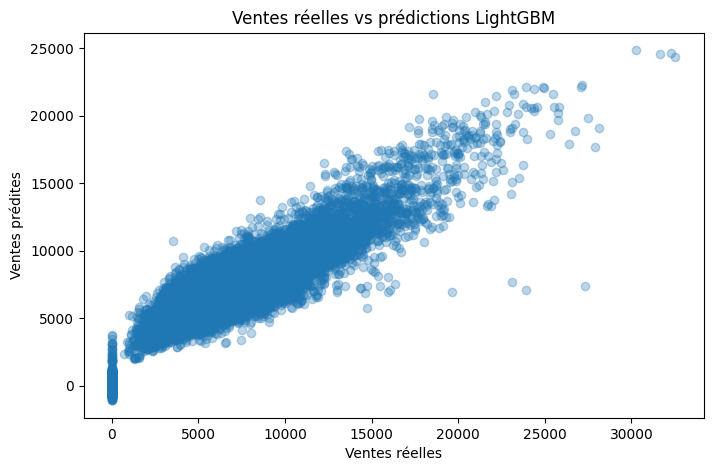

In [321]:
plt.figure(figsize=(8,5))

plt.scatter(
    error_analysis["Actual_Sales"],
    error_analysis["Predicted_Sales"],
    alpha=0.3
)

plt.xlabel("Ventes réelles")
plt.ylabel("Ventes prédites")
plt.title("Ventes réelles vs prédictions LightGBM")

plt.show()

In [322]:
joblib.dump(
    lgb_model,
    "lightgbm_sales_forecasting_model.pkl"
)

['lightgbm_sales_forecasting_model.pkl']

# 10. Explainable AI with SHAP

Machine learning models such as LightGBM often behave like
"black boxes".

To improve interpretability, SHAP (SHapley Additive exPlanations)
is used to quantify the contribution of each feature to the model's
predictions.

This allows us to understand:

- which variables globally influence predictions,
- how each feature affects sales,
- why an individual prediction was made.

### 10.1 SHAP Explainer

In [323]:
!pip install shap

In [324]:
explainer = shap.TreeExplainer(lgb_model)

In [325]:
X_shap = X_val_encoded.sample(
    5000,
    random_state=42
)

In [326]:
shap_values = explainer.shap_values(
    X_shap
)

## 10.2 Global Feature Importance

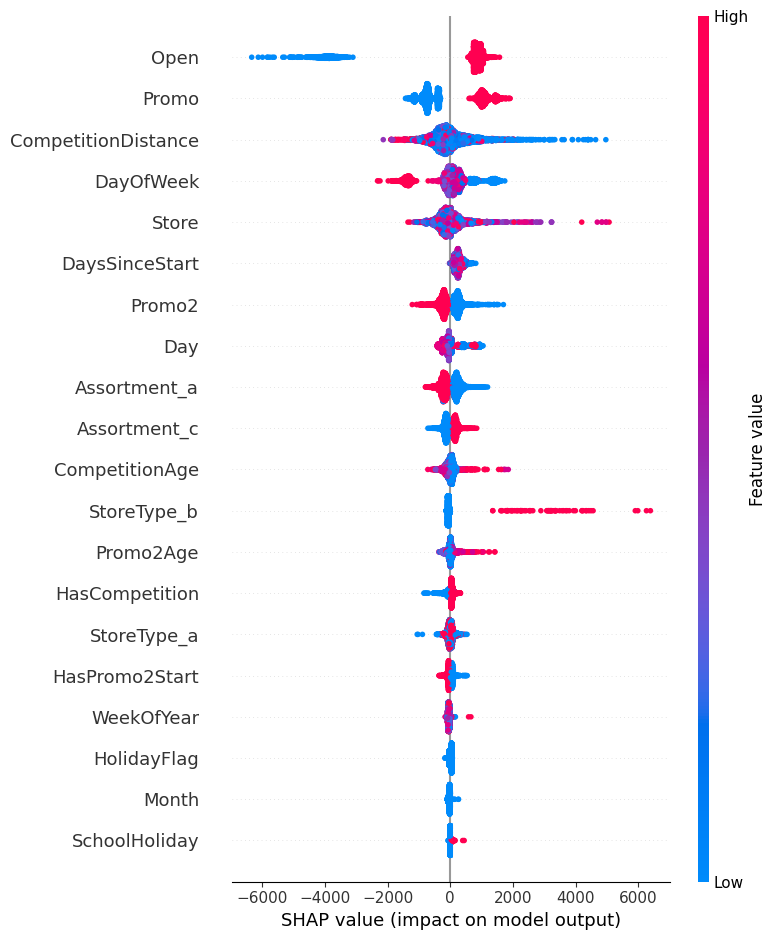

In [327]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="dot"
)

### Interpretation

The SHAP summary plot highlights the variables with the greatest
overall influence on sales predictions.

The most influential features are:

- Open
- Promo
- CompetitionDistance
- DayOfWeek
- Store
- DaysSinceStart

Promotions and store availability have the strongest positive
impact on predicted sales, while competition-related variables
and store characteristics also contribute significantly.

## 10.3 Individual Prediction Explanation

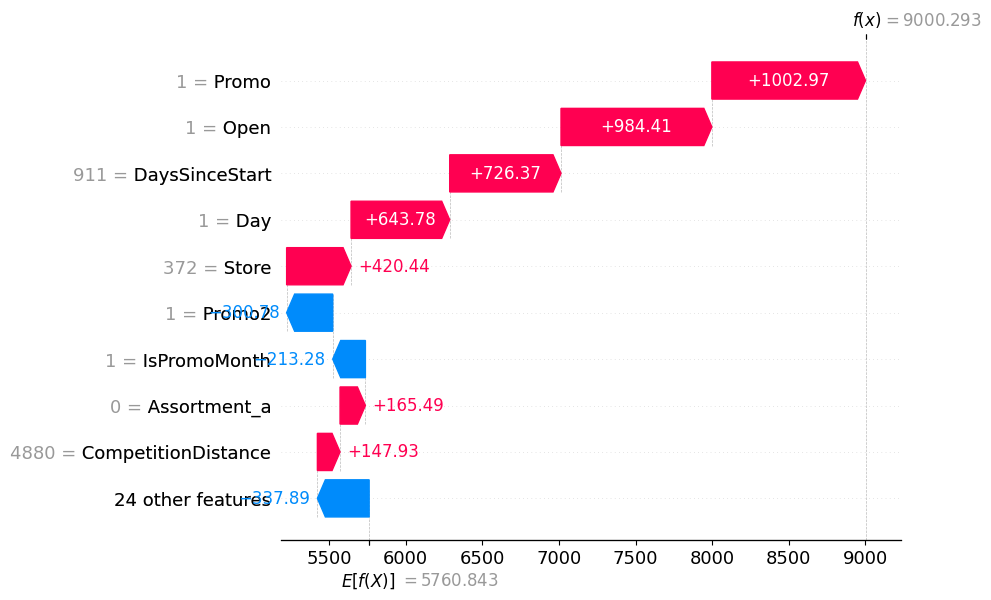

In [328]:
sample_index = 0

shap.plots.waterfall(
    explainer(
        X_val_encoded.iloc[[sample_index]]
    )[0]
)

### Interpretation

The waterfall plot explains how each feature contributes
to one individual prediction.

Positive contributions increase the predicted sales,
while negative contributions decrease it.

This visualization makes individual model decisions
fully interpretable.

## 10.4 Mean Absolute SHAP Values

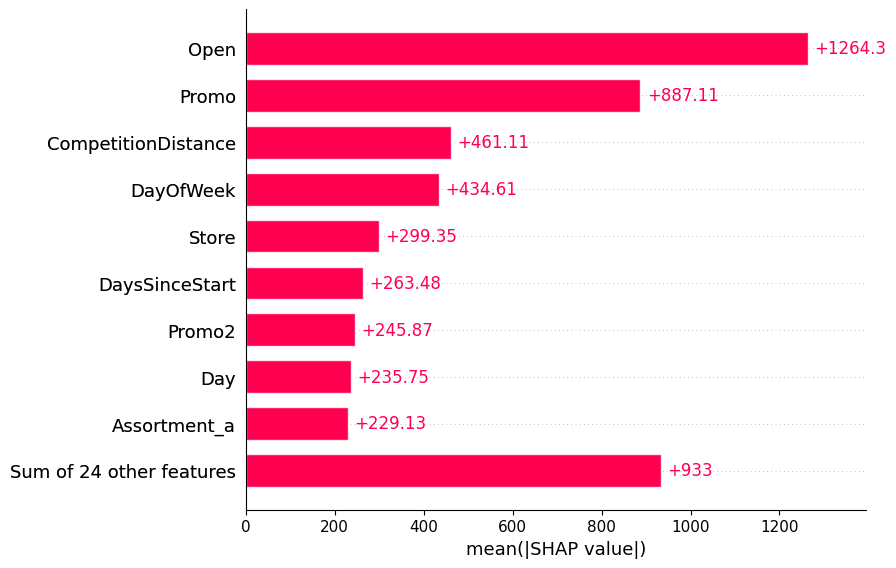

In [329]:
shap.plots.bar(
    explainer(X_val_encoded)
)

### Interpretation

The SHAP bar plot ranks variables according to their average
contribution to predictions.

Store opening status, promotions and competition-related
features remain the dominant drivers of sales forecasting.

# 11. Error Analysis

While global metrics provide an overall assessment of model performance,
it is also important to analyze prediction errors.

This section identifies situations where the model performs well and where
its predictions are less accurate, helping to understand its limitations
and potential areas for improvement.

## 12.1 Create Error Analysis Dataset

A dedicated dataset is created to compare actual sales,
predicted sales and prediction errors.

In [330]:
error_analysis = X_val_encoded.copy()

error_analysis["Actual_Sales"] = y_val.values
error_analysis["Predicted_Sales"] = y_pred_lgb

error_analysis["Error"] = (
    error_analysis["Actual_Sales"] -
    error_analysis["Predicted_Sales"]
)

error_analysis["Absolute_Error"] = (
    abs(error_analysis["Error"])
)

error_analysis.head()

,Store,DayOfWeek,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,Year,Month,Day,WeekOfYear,Quarter,IsWeekend,DaysSinceStart,IsMonthStart,IsMonthEnd,HasPromo2Start,Promo2Age,HasCompetition,CompetitionAge,HolidayFlag,IsPromoMonth,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c,Actual_Sales,Predicted_Sales,Error,Absolute_Error
33821,372,3,1,1,1,4880.0,1,2015,7,1,27,3,0,911,1,0,1,1.0,1,5.0,0,1,1,0,0,0,0,0,0,1,0,0,1,8726,9000.292502,-274.292502,274.292502
33817,368,3,1,1,0,1450.0,1,2015,7,1,27,3,0,911,1,0,1,6.0,1,10.0,0,0,1,0,0,0,0,0,0,1,0,0,1,12302,10609.280964,1692.719036,1692.719036
33818,369,3,1,1,0,5870.0,0,2015,7,1,27,3,0,911,1,0,0,0.0,1,1.0,0,0,1,0,0,0,0,0,0,1,0,0,1,7079,9324.660251,-2245.660251,2245.660251
33819,370,3,1,1,1,8250.0,1,2015,7,1,27,3,0,911,1,0,1,6.0,1,15.0,0,1,1,0,0,0,0,0,0,1,1,0,0,7460,8383.385282,-923.385282,923.385282
33820,371,3,1,1,0,1970.0,1,2015,7,1,27,3,0,911,1,0,1,1.0,1,6.0,0,0,1,0,0,0,0,0,0,1,0,0,1,6899,8945.923412,-2046.923412,2046.923412


## 12.2 Stores with Highest Prediction Errors

Average prediction errors are calculated for each store
to identify locations where forecasting is more challenging.

In [331]:
store_errors = (
    error_analysis
    .groupby("Store")["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

store_errors

,Absolute_Error
Store,
842,4809.868089
909,3979.418379
876,3864.072762
192,3835.997453
788,3610.475538
903,3495.107561
578,3493.995061
698,3365.926736
1114,3245.504366


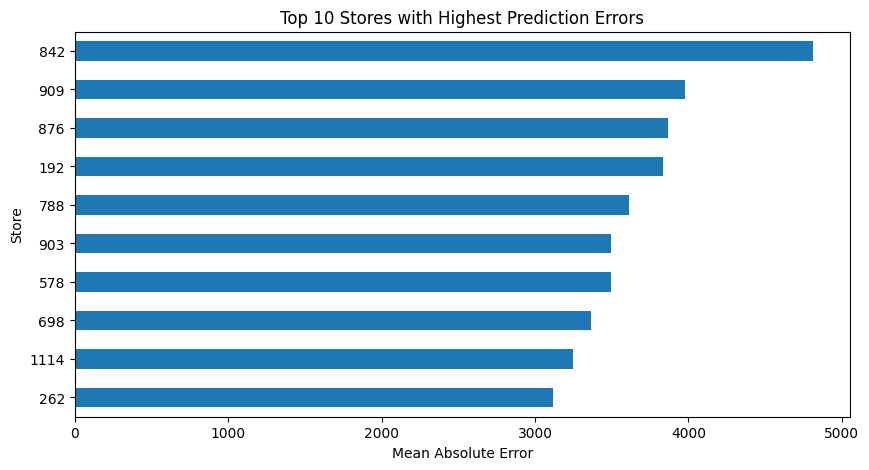

In [332]:
plt.figure(figsize=(10,5))

store_errors.sort_values().plot(
    kind="barh"
)

plt.xlabel("Mean Absolute Error")
plt.ylabel("Store")
plt.title("Top 10 Stores with Highest Prediction Errors")

plt.show()

### Interpretation

Some stores consistently present larger prediction errors.

These stores may be influenced by external factors that are
not available in the dataset, such as local events,
customer behavior or specific business conditions.

This analysis highlights opportunities for future model improvement.

## 12.3 Model Bias

The average prediction error is computed to determine whether
the model systematically overestimates or underestimates sales.

In [333]:
mean_error = error_analysis["Error"].mean()

print("Mean Error:", mean_error)

Mean Error: -236.65442652877076


### Interpretation

The mean prediction error is **-236.65**, indicating that the model
slightly overestimates sales on average.

Compared with the average daily sales (~5,774), this bias remains
relatively small and confirms that the model does not exhibit a
strong systematic prediction bias.

Overall, prediction errors remain balanced around zero, suggesting
good generalization performance.

# 12. Conclusion

## Project Summary

This project aimed to forecast daily retail sales using historical
transaction data, promotional campaigns and store characteristics.

The workflow included:

- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Time-based validation
- Machine Learning modeling with LightGBM
- Model explainability using SHAP
- Error analysis

## Results

The final LightGBM model achieved:

- RMSE: **1414**
- MAE: **1043**
- WMAPE: **16.98%**

The model successfully captures the main drivers of sales while
maintaining good prediction accuracy.

## Key Business Insights

The most influential factors affecting sales are:

- Store opening status
- Promotional campaigns
- Competition distance
- Day of week
- Store characteristics
- Time-related features

SHAP analysis confirmed that promotional activity and store availability
are the strongest contributors to sales predictions.

## Future Improvements

Model performance could be further improved by integrating additional
business information such as:

- Weather conditions
- Local events
- Public holidays by region
- Economic indicators
- Customer traffic data

These additional variables could help reduce prediction errors,
particularly for stores showing higher forecasting uncertainty.